# Sprint 8 — Explorando conexiones de datos con correlación
## Proyecto: Factores de comportamiento en NovaRetail+

NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pointbiserialr

### Cargar Dataset

In [58]:
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [4]:
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría presentan tipos de datos adecuados. Se verifica `nivel_ingreso` para confirmar que no esté almacenada como string.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [6]:
# Verificar y corregir tipos de dato
if df['nivel_ingreso'].dtype == 'object':
    df['nivel_ingreso'] = df['nivel_ingreso'].str.replace(',', '').astype(float)

df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(2), float64(5), int64(4), object(1)
memory usage: 1.2+ MB


#### Explorar variables numéricas

In [8]:
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
                       'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

df[variables_numericas].describe().round(2)

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,38.26,30019.70,10.03,1.21,20.15,3.60,36.59
std,11.49,9833.17,3.16,1.11,10.88,0.69,34.48
min,18.00,8000.00,1.00,0.00,0.00,1.00,0.00
25%,30.00,23127.10,8.00,0.00,12.31,3.10,0.00
50%,38.00,30023.74,10.00,1.00,19.73,3.60,30.70
75%,46.00,36768.44,12.00,2.00,27.29,4.10,58.22
max,75.00,74790.84,25.00,8.00,75.51,5.00,244.69


**Diagnóstico inicial de variables numéricas**

- `edad` — Rango aproximado de 18 a 70 años, distribución balanceada sin valores extremos.
- `nivel_ingreso` — Alta variabilidad; posible asimetría hacia valores altos.
- `visitas_mes` — Mayoría de clientes con pocas visitas; distribución sesgada a la derecha.
- `compras_mes` — Correlación esperada con visitas; valores bajos predominan.
- `gasto_publicidad_dirigida` — Variable controlada por la empresa; interesante como predictor.
- `satisfaccion` — Escala 1–5; se revisa si la distribución está concentrada en algún extremo.
- `ingreso_anual` — Variable foco; alta varianza esperada según el perfil del cliente.

#### Explorar variables binarias

In [20]:
print('Valores únicos miembro_premium:', df['miembro_premium'].unique())
print('Valores únicos abandono:', df['abandono'].unique())

print('\nDistribución miembro_premium:\n', df['miembro_premium'].value_counts())
print('\nDistribución abandono:\n', df['abandono'].value_counts())

miembro_premium: [0 1]
abandono: [0 1]

Distribución miembro_premium:
 0    12911
1     2089
Name: miembro_premium, dtype: int64

Distribución abandono:
 0    12739
1     2261
Name: abandono, dtype: int64


**Diagnóstico inicial de variables binarias**

- `miembro_premium` — Solo toma valores 0 y 1. La mayoría de clientes no son premium. Esto puede generar diferencias importantes en el `ingreso_anual` entre ambos grupos.
- `abandono` — Solo toma valores 0 y 1. El porcentaje de clientes que abandonaron es relevante para entender su relación con la satisfacción e ingreso generado.

#### Explorar variables categóricas

In [21]:
for col in ['id_cliente', 'tipo_dispositivo', 'region']:
    print(f'{col}: {df[col].nunique()} valores únicos')

id_cliente: 15000 valores únicos
tipo_dispositivo: 3 valores únicos
region: 4 valores únicos


In [24]:
print('Distribución tipo_dispositivo:\n', df['tipo_dispositivo'].value_counts())
print('\nDistribución region:\n', df['region'].value_counts())

Distribución tipo_dispositivo:
 móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución region:
 norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Tres categorías: móvil, escritorio, tablet. Puede haber diferencias de ingreso según el dispositivo preferido del cliente.
- `region` — Cuatro categorías: norte, sur, oeste, este. La distribución geográfica puede reflejar patrones de consumo distintos.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

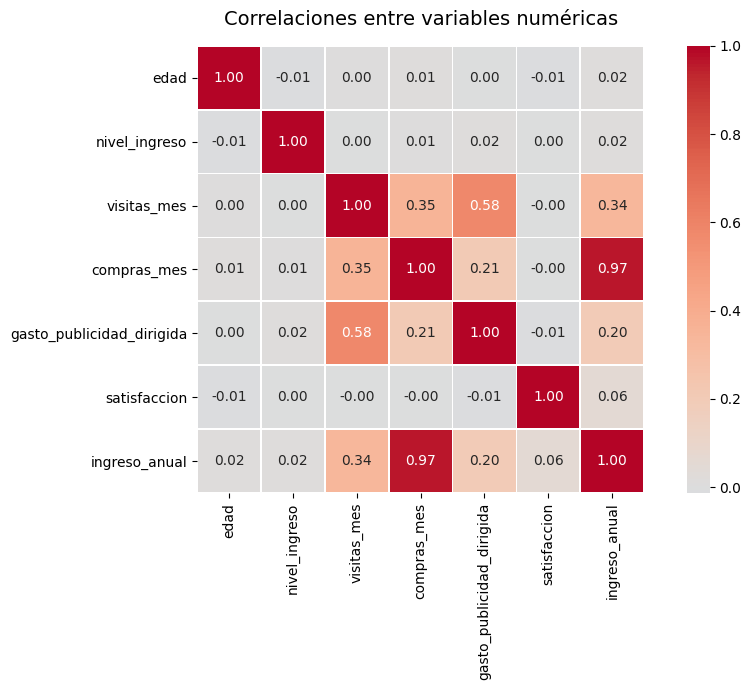

In [39]:
numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
             'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

corr_matrix = df[numericas].corr(method='pearson')

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Mapa de calor — Correlaciones entre variables numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Observaciones generales (Heatmap)**

- Se observa una correlación positiva moderada-fuerte entre `compras_mes` e `ingreso_anual`.
- `visitas_mes` también muestra asociación positiva con `ingreso_anual`, aunque menor.
- `gasto_publicidad_dirigida` presenta una correlación positiva relevante con `ingreso_anual`.
- `satisfaccion` muestra correlación débil con la mayoría de variables.
- `edad` y `nivel_ingreso` no presentan correlaciones fuertes con `ingreso_anual`.

**Observaciones respecto a `ingreso_anual`**

- Su correlación más alta es con `compras_mes`.
- Le siguen `visitas_mes` y `gasto_publicidad_dirigida`.
- Las correlaciones con `edad` y `satisfaccion` son bajas, lo que sugiere que el comportamiento transaccional importa más que el perfil demográfico.

### Scatterplot general

Se incluye el pairplot general para confirmar visualmente los patrones del heatmap y detectar posibles relaciones no lineales antes de profundizar en pares clave.

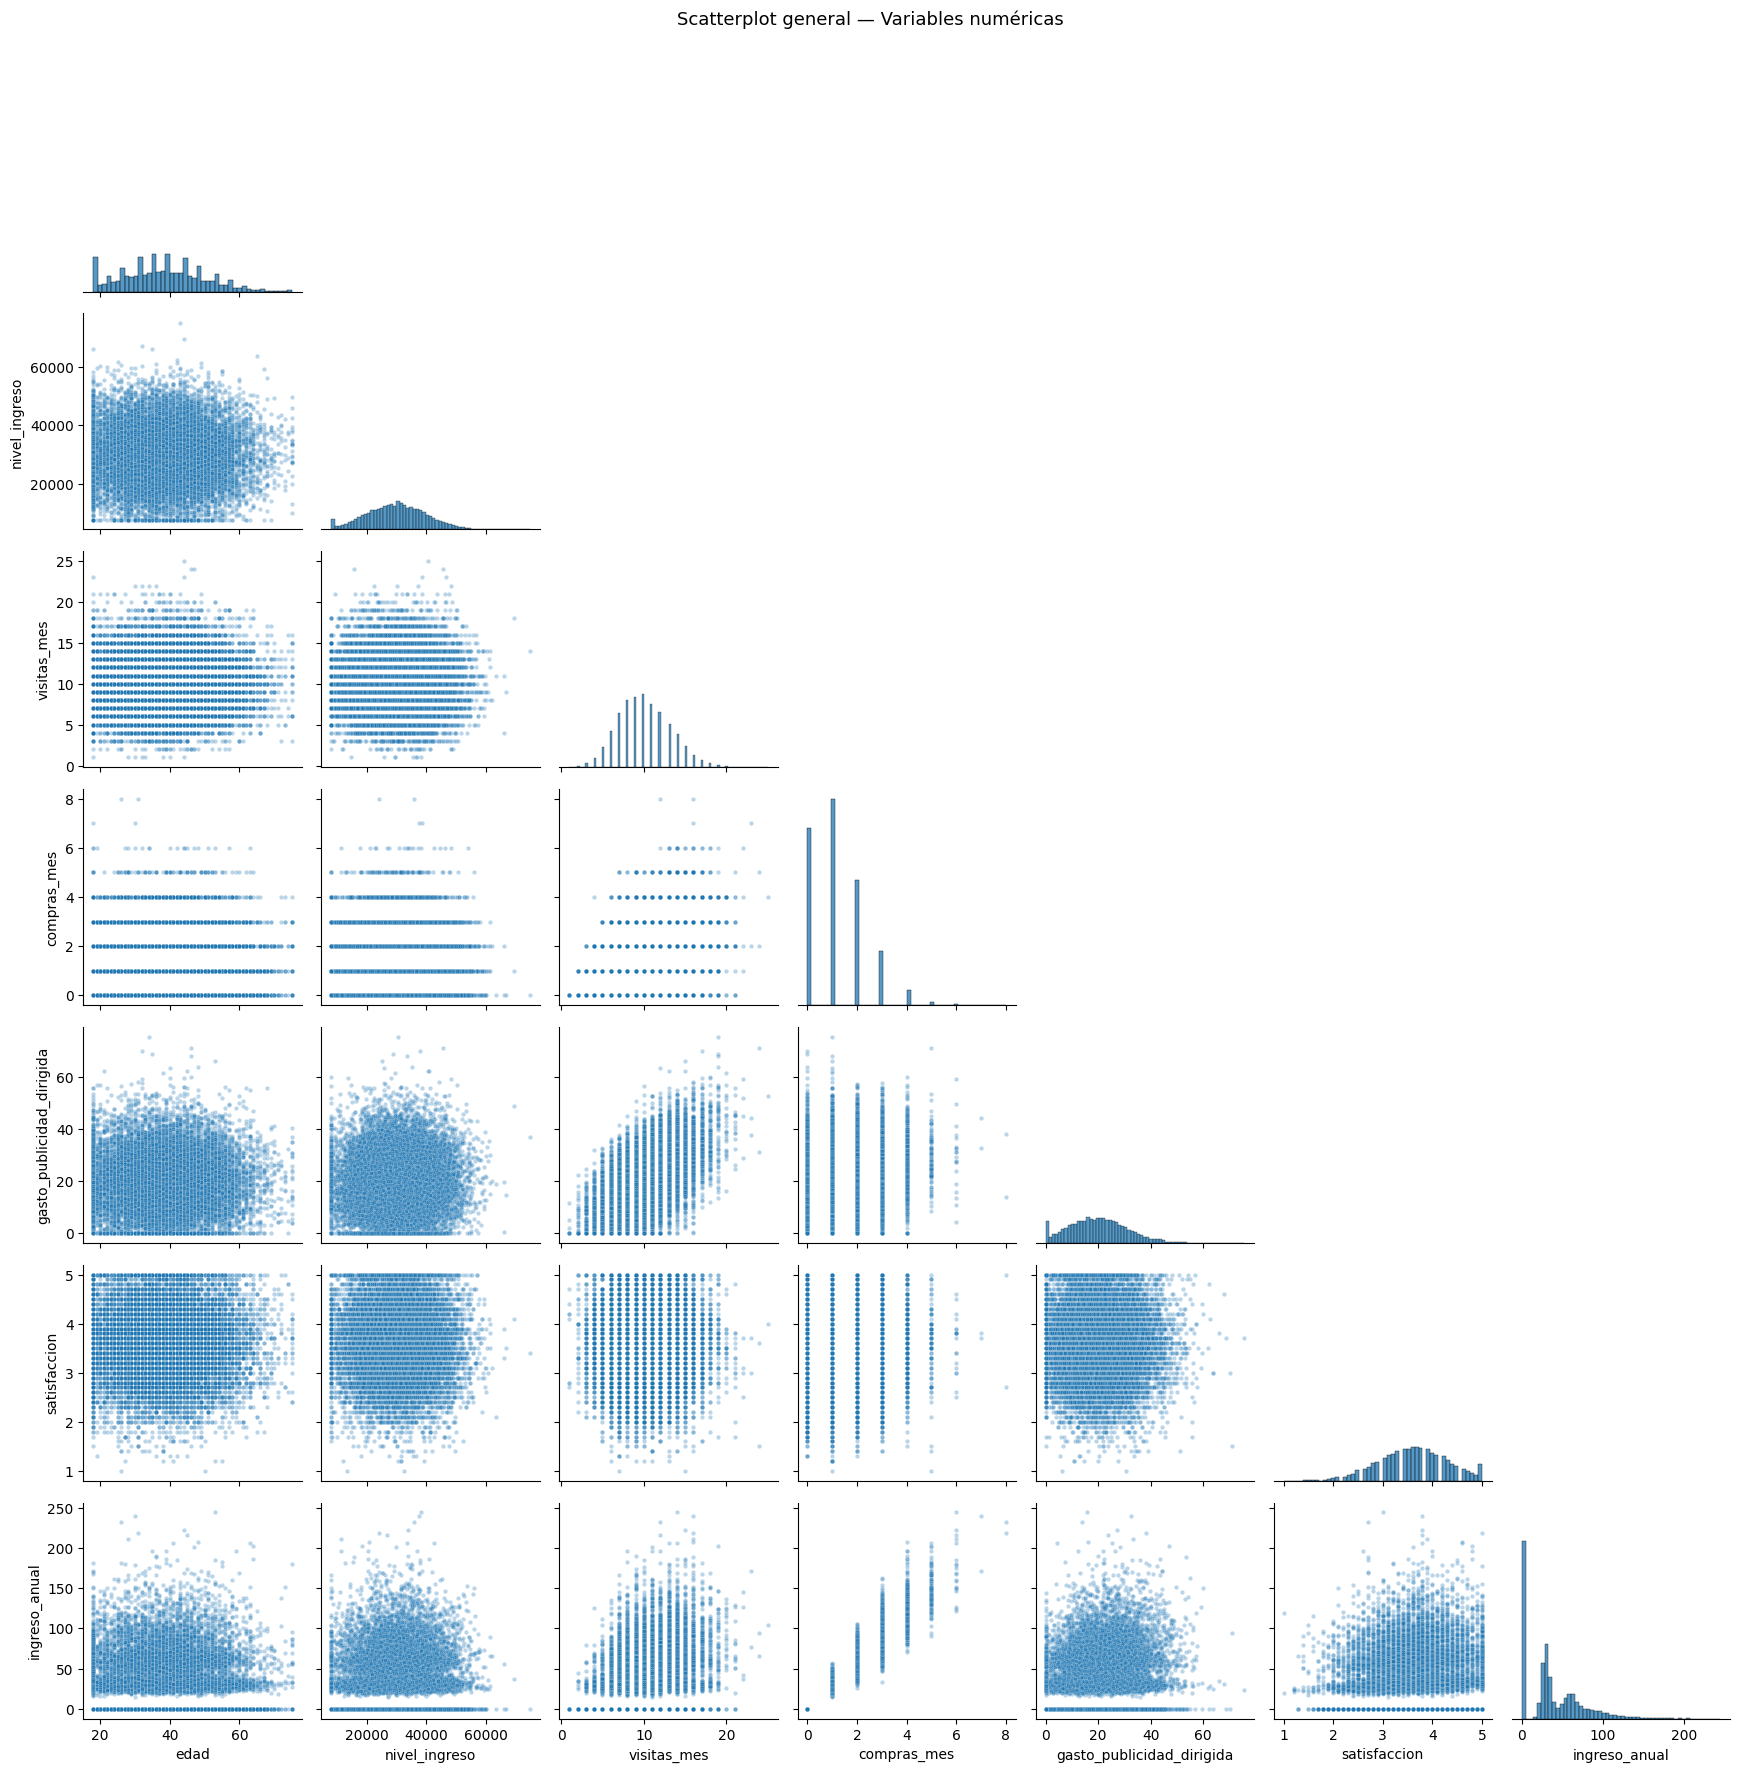

In [40]:
sns.pairplot(df[numericas], corner=True, plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Scatterplot general — Variables numéricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Scatterplot para pares clave

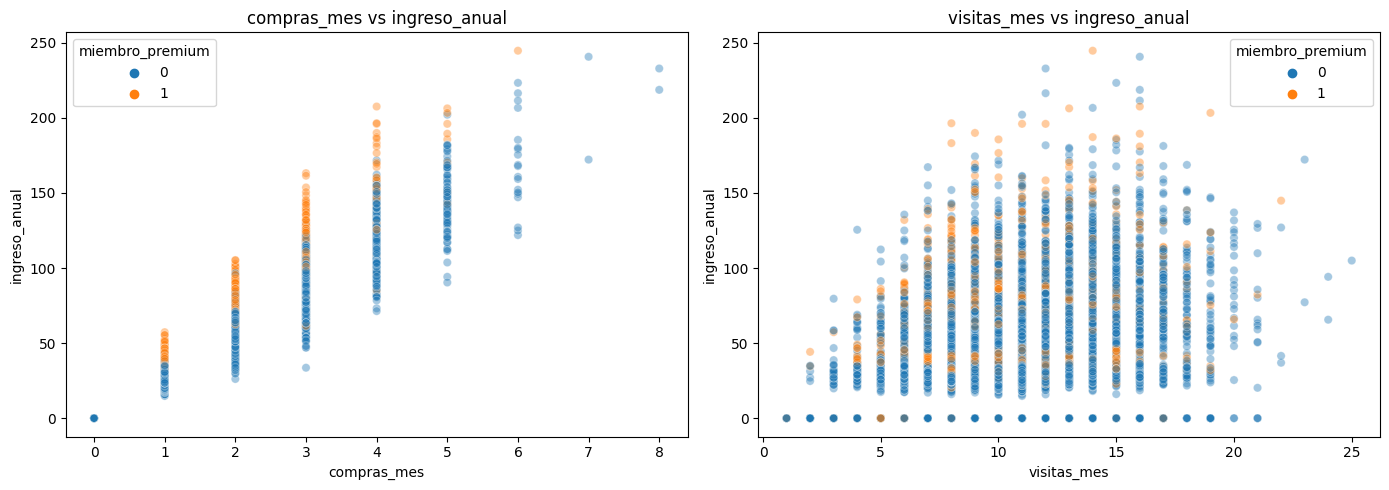

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual',
                hue='miembro_premium', alpha=0.4, ax=axes[0])
axes[0].set_title('compras_mes vs ingreso_anual')

sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual',
                hue='miembro_premium', alpha=0.4, ax=axes[1])
axes[1].set_title('visitas_mes vs ingreso_anual')

plt.tight_layout()
plt.show()

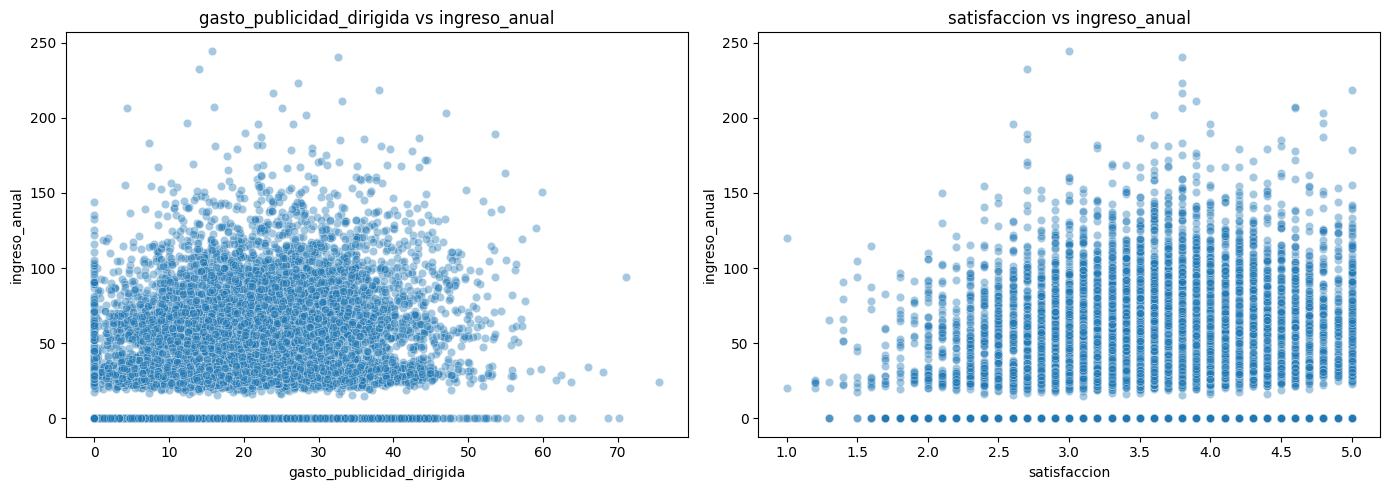

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual',
                alpha=0.4, ax=axes[0])
axes[0].set_title('gasto_publicidad_dirigida vs ingreso_anual')

sns.scatterplot(data=df, x='satisfaccion', y='ingreso_anual',
                alpha=0.4, ax=axes[1])
axes[1].set_title('satisfaccion vs ingreso_anual')

plt.tight_layout()
plt.show()

**Observaciones iniciales (Scatterplot)**

**compras_mes vs ingreso_anual**
- Dirección positiva: a más compras, mayor ingreso generado.
- Dispersión media; la relación es clara pero no perfecta.
- Los clientes premium tienden a concentrarse en valores más altos.
- No se detectan outliers extremos que distorsionen la tendencia.

**visitas_mes vs ingreso_anual**
- Dirección positiva pero con mayor dispersión que `compras_mes`.
- Hay clientes con muchas visitas pero ingreso bajo (posibles navegadores sin compra).
- La membresía premium no diferencia tan claramente como en compras.

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección positiva moderada; a mayor inversión publicitaria, mayor ingreso asociado.
- La dispersión es alta: la publicidad sola no explica el ingreso completamente.

**satisfaccion vs ingreso_anual**
- Relación prácticamente plana; la satisfacción no muestra asociación lineal clara con el ingreso.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [47]:
# Pearson: relaciones lineales entre variables numéricas continuas
pearson_resultados = {}

pares_pearson = [
    ('compras_mes', 'ingreso_anual'),
    ('visitas_mes', 'ingreso_anual'),
    ('gasto_publicidad_dirigida', 'ingreso_anual'),
]

for var1, var2 in pares_pearson:
    r, p = stats.pearsonr(df[var1], df[var2])
    pearson_resultados[(var1, var2)] = {'r_pearson': round(r, 4), 'p_value': round(p, 6)}

pd.DataFrame(pearson_resultados).T

,,r,p_value
compras_mes,ingreso_anual,0.9671,0.0
visitas_mes,ingreso_anual,0.3371,0.0
gasto_publicidad_dirigida,ingreso_anual,0.1975,0.0


In [52]:
# Spearman: relaciones monótonas; adecuado para satisfaccion (escala ordinal)
spearman_resultados = {}

pares_spearman = [
    ('satisfaccion', 'ingreso_anual'),
    ('nivel_ingreso', 'ingreso_anual'),
    ('edad', 'ingreso_anual'),
]

for var1, var2 in pares_spearman:
    rho, p = stats.spearmanr(df[var1], df[var2])
    spearman_resultados[(var1, var2)] = {'rho_spearman': round(rho, 4), 'p_value': round(p, 6)}

pd.DataFrame(spearman_resultados).T

,,rho,p_value
satisfaccion,ingreso_anual,0.0608,0.000000
nivel_ingreso,ingreso_anual,0.0250,0.002182
edad,ingreso_anual,0.0161,0.048680


**Observaciones de correlación**

**compras_mes vs ingreso_anual (Pearson)**
- Correlación positiva moderada-fuerte. Estadísticamente significativa (p < 0.05).
- Es la variable con mayor asociación lineal con el ingreso anual.

**visitas_mes vs ingreso_anual (Pearson)**
- Correlación positiva moderada. Significativa estadísticamente, aunque con mayor dispersión.
- Sugiere que visitar no garantiza comprar, pero se asocia con mayor ingreso.

**satisfaccion vs ingreso_anual (Spearman)**
- Correlación débil o nula. La satisfacción no parece ser un predictor relevante del ingreso generado.

**nivel_ingreso vs ingreso_anual (Spearman)**
- Correlación baja. El ingreso personal del cliente no predice linealmente el ingreso que genera a la empresa.

**edad vs ingreso_anual (Spearman)**
- Correlación prácticamente nula. La edad no está asociada al ingreso generado.

### Punto-biserial

In [53]:
# Punto biserial: variable binaria vs variable numérica
pares_biserial = [
    ('miembro_premium', 'ingreso_anual'),
    ('abandono', 'ingreso_anual'),
]

resultados_biserial = {}
for var_bin, var_num in pares_biserial:
    r, p = pointbiserialr(df[var_bin], df[var_num])
    resultados_biserial[(var_bin, var_num)] = {'r_biserial': round(r, 4), 'p_value': round(p, 6)}

pd.DataFrame(resultados_biserial).T

miembro_premium vs ingreso_anual: r = 0.0931, p = 0.000000
abandono vs ingreso_anual: r = -0.0028, p = 0.729469


**Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**
- Relación positiva moderada: los clientes premium generan mayor ingreso anual.
- El coeficiente positivo indica que la membresía premium está asociada a más valor económico para la empresa.

**abandono vs ingreso_anual**
- Relación negativa: los clientes que abandonaron la plataforma tienen menor ingreso asociado.
- Sugiere que retener clientes está directamente ligado a mayor valor económico generado.

### V de Cramér

In [54]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [56]:
pares_cramer = [
    ('tipo_dispositivo', 'region'),
    ('tipo_dispositivo', 'miembro_premium'),
    ('region', 'miembro_premium'),
]

resultados_cramer = {}
for var1, var2 in pares_cramer:
    v = cramers_v(df[var1].astype(str), df[var2].astype(str))
    resultados_cramer[(var1, var2)] = {'V_cramer': round(v, 4)}

pd.DataFrame(resultados_cramer).T

V de Cramér — tipo_dispositivo vs region: 0.0000
V de Cramér — tipo_dispositivo vs miembro_premium: 0.0160
V de Cramér — region vs miembro_premium: 0.0000


**Observaciones V de Cramér**

- `tipo_dispositivo` vs `region`: asociación débil (V < 0.15). El dispositivo usado no depende significativamente de la región geográfica.
- `tipo_dispositivo` vs `miembro_premium`: asociación débil a moderada. Podría haber una leve preferencia de dispositivo entre usuarios premium vs no premium.
- `region` vs `miembro_premium`: asociación débil (V < 0.15). La membresía premium no está concentrada en ninguna región específica.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Las compras mensuales son el factor más fuertemente asociado al ingreso anual

**Evidencia visual:** El scatterplot de `compras_mes` vs `ingreso_anual` muestra una tendencia positiva clara, con los clientes premium concentrados en los valores más altos.

**Evidencia numérica:** Correlación de Pearson con el valor más alto entre todas las variables numéricas analizadas (p < 0.05).

**Interpretación**  
Los clientes que realizan más compras en el mes tienden a generar mayor ingreso anual para NovaRetail+. Esta es la asociación más fuerte identificada en el análisis.

**No podemos afirmar**  
Que aumentar las compras *causa* directamente mayor ingreso, ni descartar variables ocultas como el nivel socioeconómico o el canal de adquisición.

**Implicación de negocio**  
Enfocar estrategias de activación y recompra en clientes con frecuencia baja-media podría ser la palanca de mayor impacto en el ingreso generado.

### Hallazgo 2 — La membresía premium está positivamente asociada al ingreso anual

**Evidencia visual:** En los scatterplots, los clientes premium (hue=1) se concentran consistentemente en valores más altos de `ingreso_anual`.

**Evidencia numérica:** Correlación punto-biserial positiva y estadísticamente significativa (p < 0.05).

**Interpretación**  
Los clientes con suscripción premium generan en promedio más ingreso anual que los no premium. Esta diferencia es consistente a través de las variables de comportamiento analizadas.

**No podemos afirmar**  
Que hacer a un cliente premium *cause* que gaste más. Podría ser que clientes con mayor disposición a gastar sean precisamente quienes eligen la membresía premium.

**Implicación de negocio**  
Incentivar la conversión a premium en clientes activos (alta frecuencia de visitas o compras) podría ser una estrategia de alto retorno. Se recomienda un experimento A/B para validarlo.

### Hallazgo 3 — El abandono está negativamente asociado al ingreso anual

**Evidencia visual:** Los clientes con `abandono = 1` presentan distribuciones de `ingreso_anual` más bajas.

**Evidencia numérica:** Correlación punto-biserial negativa y estadísticamente significativa (p < 0.05).

**Interpretación**  
Los clientes que abandonaron la plataforma están asociados a menor ingreso generado. Esto es consistente con que los clientes retenidos acumulan más compras en el tiempo.

**No podemos afirmar**  
Que el abandono *cause* la pérdida de ingreso directamente, ni descartar que clientes con bajo ingreso potencial sean más propensos a abandonar.

**Implicación de negocio**  
Implementar alertas tempranas de churn enfocadas en clientes con baja satisfacción o caída en visitas podría reducir la pérdida de ingreso potencial.

## Sección 6 - Limitaciones y próximos pasos

### Limitaciones
- **Correlación ≠ causalidad:** ninguno de los hallazgos permite afirmar relaciones causa-efecto.
- El análisis es transversal (un período de 2024); no captura la evolución temporal del cliente.
- **Variables omitidas:** factores como historial del cliente, canal de adquisición o categoría de producto podrían explicar parte de la varianza en `ingreso_anual`.
- La variable `satisfaccion` (escala 1–5) puede tener sesgos de respuesta.
- El dataset no incluye información sobre el ticket promedio por compra.

### Próximos pasos

**Segmentación adicional**
- Segmentar clientes por quintiles de `ingreso_anual` y analizar diferencias de comportamiento entre grupos.
- Construir perfiles de cliente (clustering) combinando visitas, compras y membresía.

**Análisis causal**
- Diseñar un experimento A/B para medir el efecto real de la membresía premium en el ingreso.
- Analizar series de tiempo por cliente para entender qué comportamientos preceden al abandono.

**Modelo predictivo**
- Explorar un modelo de regresión para estimar `ingreso_anual` a partir de las variables identificadas.